# Demo Validation 1: Does the Simple Event-Count Framework Work?

Here we validate the inference pipeline using synthetic data. We first simulate datasets with known parameter values. We then apply Bayesian inference to each dataset and compare the inferred posterior distributions with the true simulation parameters.

The aim is to quantify how inference accuracy depends on the amount of available data. By increasing the dataset size, we assess when the posterior becomes sufficiently concentrated around the true values and when uncertainty remains too large for reliable interpretation.

This validation provides a practical estimate of the minimum amount of data required for robust parameter inference in the subsequent analysis of NK cell contact and kill events.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

CACHE_ROOT = Path(os.environ.get("TMPDIR", "/tmp"))
os.environ.setdefault("PYTENSOR_FLAGS", "optimizer_excluding=fusion")
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_ROOT / ".cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)


import arviz as az
import numpy as np
import pandas as pd
import pymc as pm


import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, NullLocator
try:
    import scienceplots
    plt.style.use('science')
except ModuleNotFoundError:
    plt.style.use('default')


def find_section_root(start: Path | None = None, folder_name: str = "section_1") -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if path.name == folder_name:
            return path

        candidate = path / folder_name
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError(f"Could not find {folder_name!r} from {start}")


SECTION_ROOT = find_section_root()
PROJECT_ROOT = SECTION_ROOT.parent
SRC_ROOT = SECTION_ROOT / "src"

for path in (PROJECT_ROOT, SECTION_ROOT, SRC_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("We are currently in: ", SECTION_ROOT)
print("The source python scripts folder is: ", SRC_ROOT)

print("\nSource scripts:")
for path in sorted(SRC_ROOT.glob("*.py")):
    print("-", path.name)


We are currently in:  /Users/marsian/PhD_LifeSciRes/Orca/section_1
The source python scripts folder is:  /Users/marsian/PhD_LifeSciRes/Orca/section_1/src

Source scripts:
- inference.py
- simulator.py


## Step 1. synthetic data generation

`src/simulator.py`

This script generates synthetic event-count data from the proposed NK cell interaction model. It simulates cell-specific event rates and observed event counts under homogeneous and heterogeneous population assumptions.

In the heterogeneous model, each NK cell is assigned an event rate from a zero-inflated Gamma distribution. A fraction of cells ($
\phi_0$) is inactive and has rate zero. The remaining active cells ($1-\phi_0$) have Gamma-distributed rates with mean $\mu_\lambda$ and variability $\sigma_\lambda$. Given each cell-specific rate $\lambda_i$, the observed number of events is generated from a Poisson process over a fixed observation window, with $T=1$ by default.

Here I show you a demonstration of the synthetic data generation.

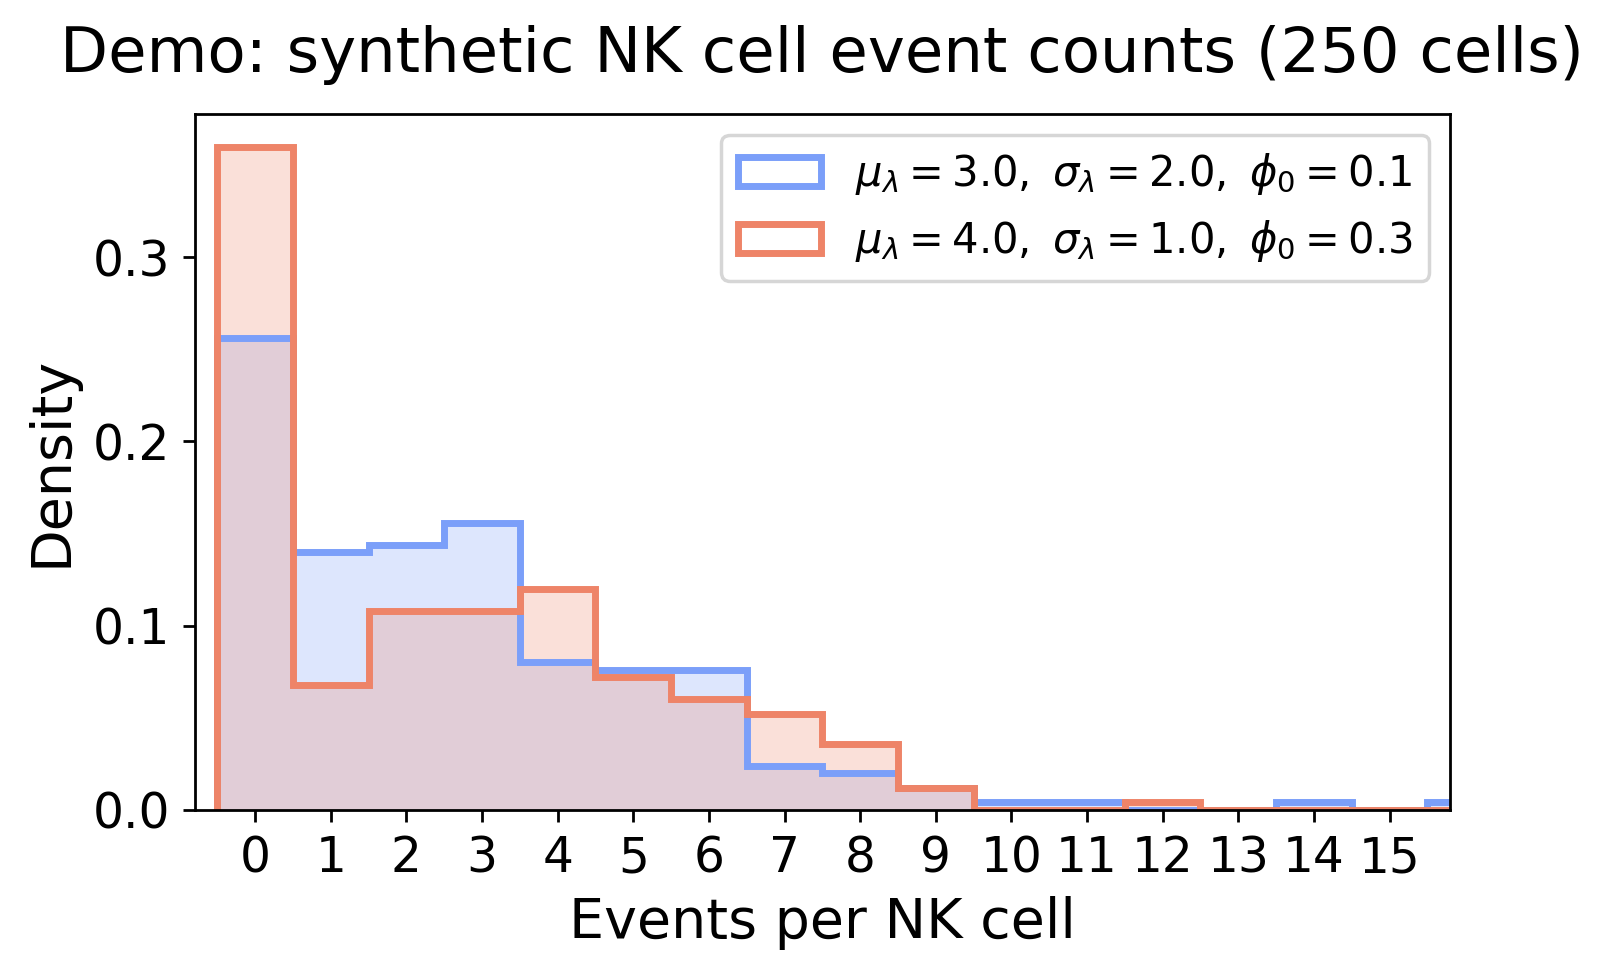

In [2]:
from simulator import simulate_Population

demo_params = [
    {"mu_lambda": 3.0, "sd_lambda": 2.0, "p0_lambda": 0.1},
    {"mu_lambda": 4.0, "sd_lambda": 1.0, "p0_lambda": 0.3},
]
NUM_CELLS = 250
datasets = [
    simulate_Population(
        n_cells=NUM_CELLS,
        T=1.0,
        mode="heterogeneous",
        **params,
    )["n_events"]
    for params in demo_params
]

labels = [
    rf"$\mu_\lambda={p['mu_lambda']},\ \sigma_\lambda={p['sd_lambda']},\ \phi_0={p['p0_lambda']}$"
    for p in demo_params
]

cmap = plt.colormaps["coolwarm"]
colors = cmap(np.linspace(0.2, 0.8, len(datasets)))

bins = np.arange(-0.5, 20.5, 1)


fig, ax = plt.subplots(figsize=(6, 4), dpi=250)

for data, label, color in zip(datasets, labels, colors):
    ax.hist(data, bins=bins, density=True, histtype="stepfilled", alpha=0.25, color=color)
    ax.hist(data, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=label)

ax.set_xlim(-0.8, 15.8)
ax.set_xticks(np.arange(0, 16, 1))
ax.tick_params(axis="both", labelsize=14)
ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

ax.set_title(f"Demo: synthetic NK cell event counts ({NUM_CELLS} cells)", fontsize=18, pad=12)
ax.set_xlabel("Events per NK cell", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.legend(frameon=True, fontsize=12)

fig.tight_layout()
plt.show()

## Step 2. Bayesian Inference on Synthetic Data

The we use Bayesian inference infer the parameters of the event-count framework from synthetic data. Given the simulated event counts, it estimates the population-level parameters ($\mu_\lambda, \sigma_\lambda, \phi_0$).

Bayesian inference code: `src/inference.py`

The inferred posterior distributions are compared with the known simulation parameters. This allows us to evaluate whether the inference pipeline can recover the ground truth under controlled conditions.

**Define the posterior visualisation function**

In [3]:
from inference import inference_homo, inference_Z2P, inference_Dis2P, inference_hetero3

def plot_posteriors(
    idatas: Sequence[Tuple[str, az.InferenceData]],
    *,
    ground_truth: Optional[Dict[str, Dict[str, float]]] = None,
    parameters: Sequence[str],
    parameter_display: Optional[Dict[str, str]] = None,
    show_legend: bool = True,
    hdi_prob: float = 0.95,
    sample_size: int = 200000,
    save_path: str | Path = "posteriors",
    cmap_name: str = "inferno",
    font_scale: float = 0.7,
    diagonal_style: str = "hist",
    marginal_style: str = "circle",
    seed: Optional[int] = None,
    dpi: int = 300,
    xlims: Optional[Dict[str, Tuple[float, float]]] = None,
) -> None:
    sns.set_context("talk", font_scale=float(font_scale))
    if len(idatas) == 1:
        colors = ["black"]
    else:
        cmap = plt.colormaps.get_cmap(str(cmap_name))
        colors = cmap(np.linspace(0.3, 0.9, len(idatas)))
    rng = np.random.default_rng(seed)

    params = [str(p) for p in parameters]
    if parameter_display is None:
        parameter_display = {p: p for p in params}

    def _posterior_vals(posterior, name: str) -> np.ndarray:
        if name in posterior:
            vals = posterior[name].stack(sample=("chain", "draw")).values.ravel()
            vals = np.asarray(vals, dtype=float)
            return vals[np.isfinite(vals)]
        return np.array([], dtype=float)

    label_to_df: Dict[str, pd.DataFrame] = {}
    for label, idata in idatas:
        posterior = idata.posterior
        df = pd.DataFrame()
        for p in params:
            vals = _posterior_vals(posterior, p)
            if vals.size == 0:
                continue
            if vals.size > int(sample_size):
                idx = rng.choice(vals.size, int(sample_size), replace=False)
                vals = vals[idx]
            df[p] = vals
        if not df.empty:
            df["label"] = label
            label_to_df[label] = df

    def _robust_limits(all_vals: np.ndarray) -> Optional[Tuple[float, float]]:
        all_vals = np.asarray(all_vals, dtype=float)
        all_vals = all_vals[np.isfinite(all_vals)]
        if all_vals.size == 0:
            return None
        lo = float(np.quantile(all_vals, 0.005))
        hi = float(np.quantile(all_vals, 0.995))
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo = float(np.min(all_vals))
            hi = float(np.max(all_vals))
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return None
        pad = 0.03 * (hi - lo)
        return lo - pad, hi + pad

    param_xlims: Dict[str, Tuple[float, float]] = {}
    for p in params:
        cols: List[np.ndarray] = []
        for _lab, _df in label_to_df.items():
            if p in _df.columns:
                arr = np.asarray(_df[p].values, dtype=float)
                arr = arr[np.isfinite(arr)]
                if arr.size:
                    cols.append(arr)
        if cols:
            lims = _robust_limits(np.concatenate(cols))
            if lims is not None:
                param_xlims[p] = lims

    if xlims:
        for k, v in xlims.items():
            if k in params and v is not None:
                param_xlims[k] = (float(v[0]), float(v[1]))

    npar = len(params)
    fig = plt.figure(figsize=(5 * npar, 5 * npar), dpi=int(dpi))
    fig.patch.set_alpha(0.0)
    gs = gridspec.GridSpec(npar, npar, wspace=0.35, hspace=0.35)
    gaxes = np.empty((npar, npar), dtype=object)

    for irow, rowpar in enumerate(params):
        for icol, colpar in enumerate(params):
            ax = plt.subplot(gs[irow, icol])
            gaxes[irow, icol] = ax
            ax.set_facecolor("none")
            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())

            if icol > irow:
                ax.axis("off")
                continue

            for color, (label, df) in zip(colors, label_to_df.items()):
                if icol == irow:
                    if rowpar not in df.columns:
                        continue
                    vals = df[rowpar].dropna().values
                    if vals.size == 0:
                        continue

                    if diagonal_style == "kde":
                        sns.kdeplot(
                            vals,
                            ax=ax,
                            fill=True,
                            color=color,
                            alpha=0.2,
                            linewidth=1.5,
                            label=(label if (bool(show_legend) and irow == 0) else None),
                        )
                    else:
                        sns.histplot(vals, bins=30, stat="density", kde=False, ax=ax, color=color, alpha=0.18, element="step", fill=True)
                        sns.histplot(
                            vals,
                            bins=30,
                            stat="density",
                            kde=False,
                            ax=ax,
                            color=color,
                            alpha=1.0,
                            element="step",
                            fill=False,
                            linewidth=1.8,
                            label=(label if (bool(show_legend) and irow == 0) else None),
                        )

                    try:
                        lo, hi = az.hdi(vals, hdi_prob=float(hdi_prob))
                        ax.axvspan(float(lo), float(hi), color=color, alpha=0.1, linewidth=0)
                    except Exception:
                        pass

                    if ground_truth is not None and label in ground_truth and rowpar in ground_truth[label]:
                        ax.axvline(float(ground_truth[label][rowpar]), color=color, linestyle="-", linewidth=1.8)

                    ax.grid(alpha=0.2)
                else:
                    if (colpar not in df.columns) or (rowpar not in df.columns):
                        continue
                    if marginal_style == "circle":
                        sns.kdeplot(x=df[colpar], y=df[rowpar], ax=ax, fill=False, color=color, alpha=0.6, levels=7, linewidths=1.0)
                    else:
                        sns.histplot(x=df[colpar], y=df[rowpar], bins=60, pthresh=0.01, cmap=str(cmap_name), cbar=False, ax=ax)

            if icol != irow:
                ax.grid(alpha=0.3)
                if ground_truth is not None:
                    for color, (label, _df) in zip(colors, label_to_df.items()):
                        gt = ground_truth.get(label)
                        if gt and (colpar in gt) and (rowpar in gt):
                            ax.scatter(gt[colpar], gt[rowpar], marker="*", color=color, s=80, linewidths=2.0, zorder=1000)

            if icol == irow:
                ax.set_xlabel(parameter_display.get(rowpar, rowpar))
                ax.set_ylabel("Density")
            else:
                ax.set_xlabel(parameter_display.get(colpar, colpar))
                ax.set_ylabel(parameter_display.get(rowpar, rowpar))

            if icol == irow:
                xpar = rowpar
                if xpar in param_xlims:
                    ax.set_xlim(*param_xlims[xpar])
            else:
                if colpar in param_xlims:
                    ax.set_xlim(*param_xlims[colpar])
                if rowpar in param_xlims:
                    ax.set_ylim(*param_xlims[rowpar])

            ax.margins(0.05)

    if bool(show_legend):
        handles, leg_labels = gaxes[0, 0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, leg_labels, loc="center", bbox_to_anchor=(0.85, 0.85), frameon=True, edgecolor="black", fontsize=10)


**One demo example**

In [4]:
demo_params = [
    {"mu_lambda": 3.0, "sd_lambda": 2.0, "p0_lambda": 0.1},
]

NUM_CELLS = 250
T = 1.0

datasets = [
    simulate_Population(
        n_cells=NUM_CELLS,
        T=T,
        mode="heterogeneous",
        **params,
    )["n_events"]
    for params in demo_params
]

model_specs = {
    "hetero3": {
        "fn": inference_hetero3,
        "vars": ["mu_lambda", "sigma_lambda", "p_zero"],
        "truth": {
            "mu_lambda": demo_params[0]["mu_lambda"],
            "sigma_lambda": demo_params[0]["sd_lambda"],
            "p_zero": demo_params[0]["p0_lambda"],
        },
    },
}

inference_results = []

for dataset_idx, counts in enumerate(datasets):
    result = {"dataset_idx": dataset_idx, "counts": counts, "models": {}}

    for model_name, spec in model_specs.items():
        print(f"Running {model_name}...")
        pack = spec["fn"](
            counts,
            T,
            draws=3000,
            chains=4,
            cores=4,
            lambda_prior_bounds=(-5.0, 2.0),
            random_seed=123,
        )
        result["models"][model_name] = pack

    inference_results.append(result)

Initializing SMC sampler...


Sampling 4 chains in 4 jobs


Output()

Running hetero3...


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
eta           0.467  0.030   0.409    0.522      0.000    0.000   11699.0   
sigma_lambda  1.978  0.213   1.597    2.394      0.002    0.001   12047.0   
p_zero        0.068  0.038   0.004    0.131      0.000    0.000   10276.0   
mu_lambda     2.936  0.205   2.557    3.318      0.002    0.001   11699.0   

              ess_tail  r_hat  
eta            11610.0    1.0  
sigma_lambda   11509.0    1.0  
p_zero          9435.0    1.0  
mu_lambda      11610.0    1.0  


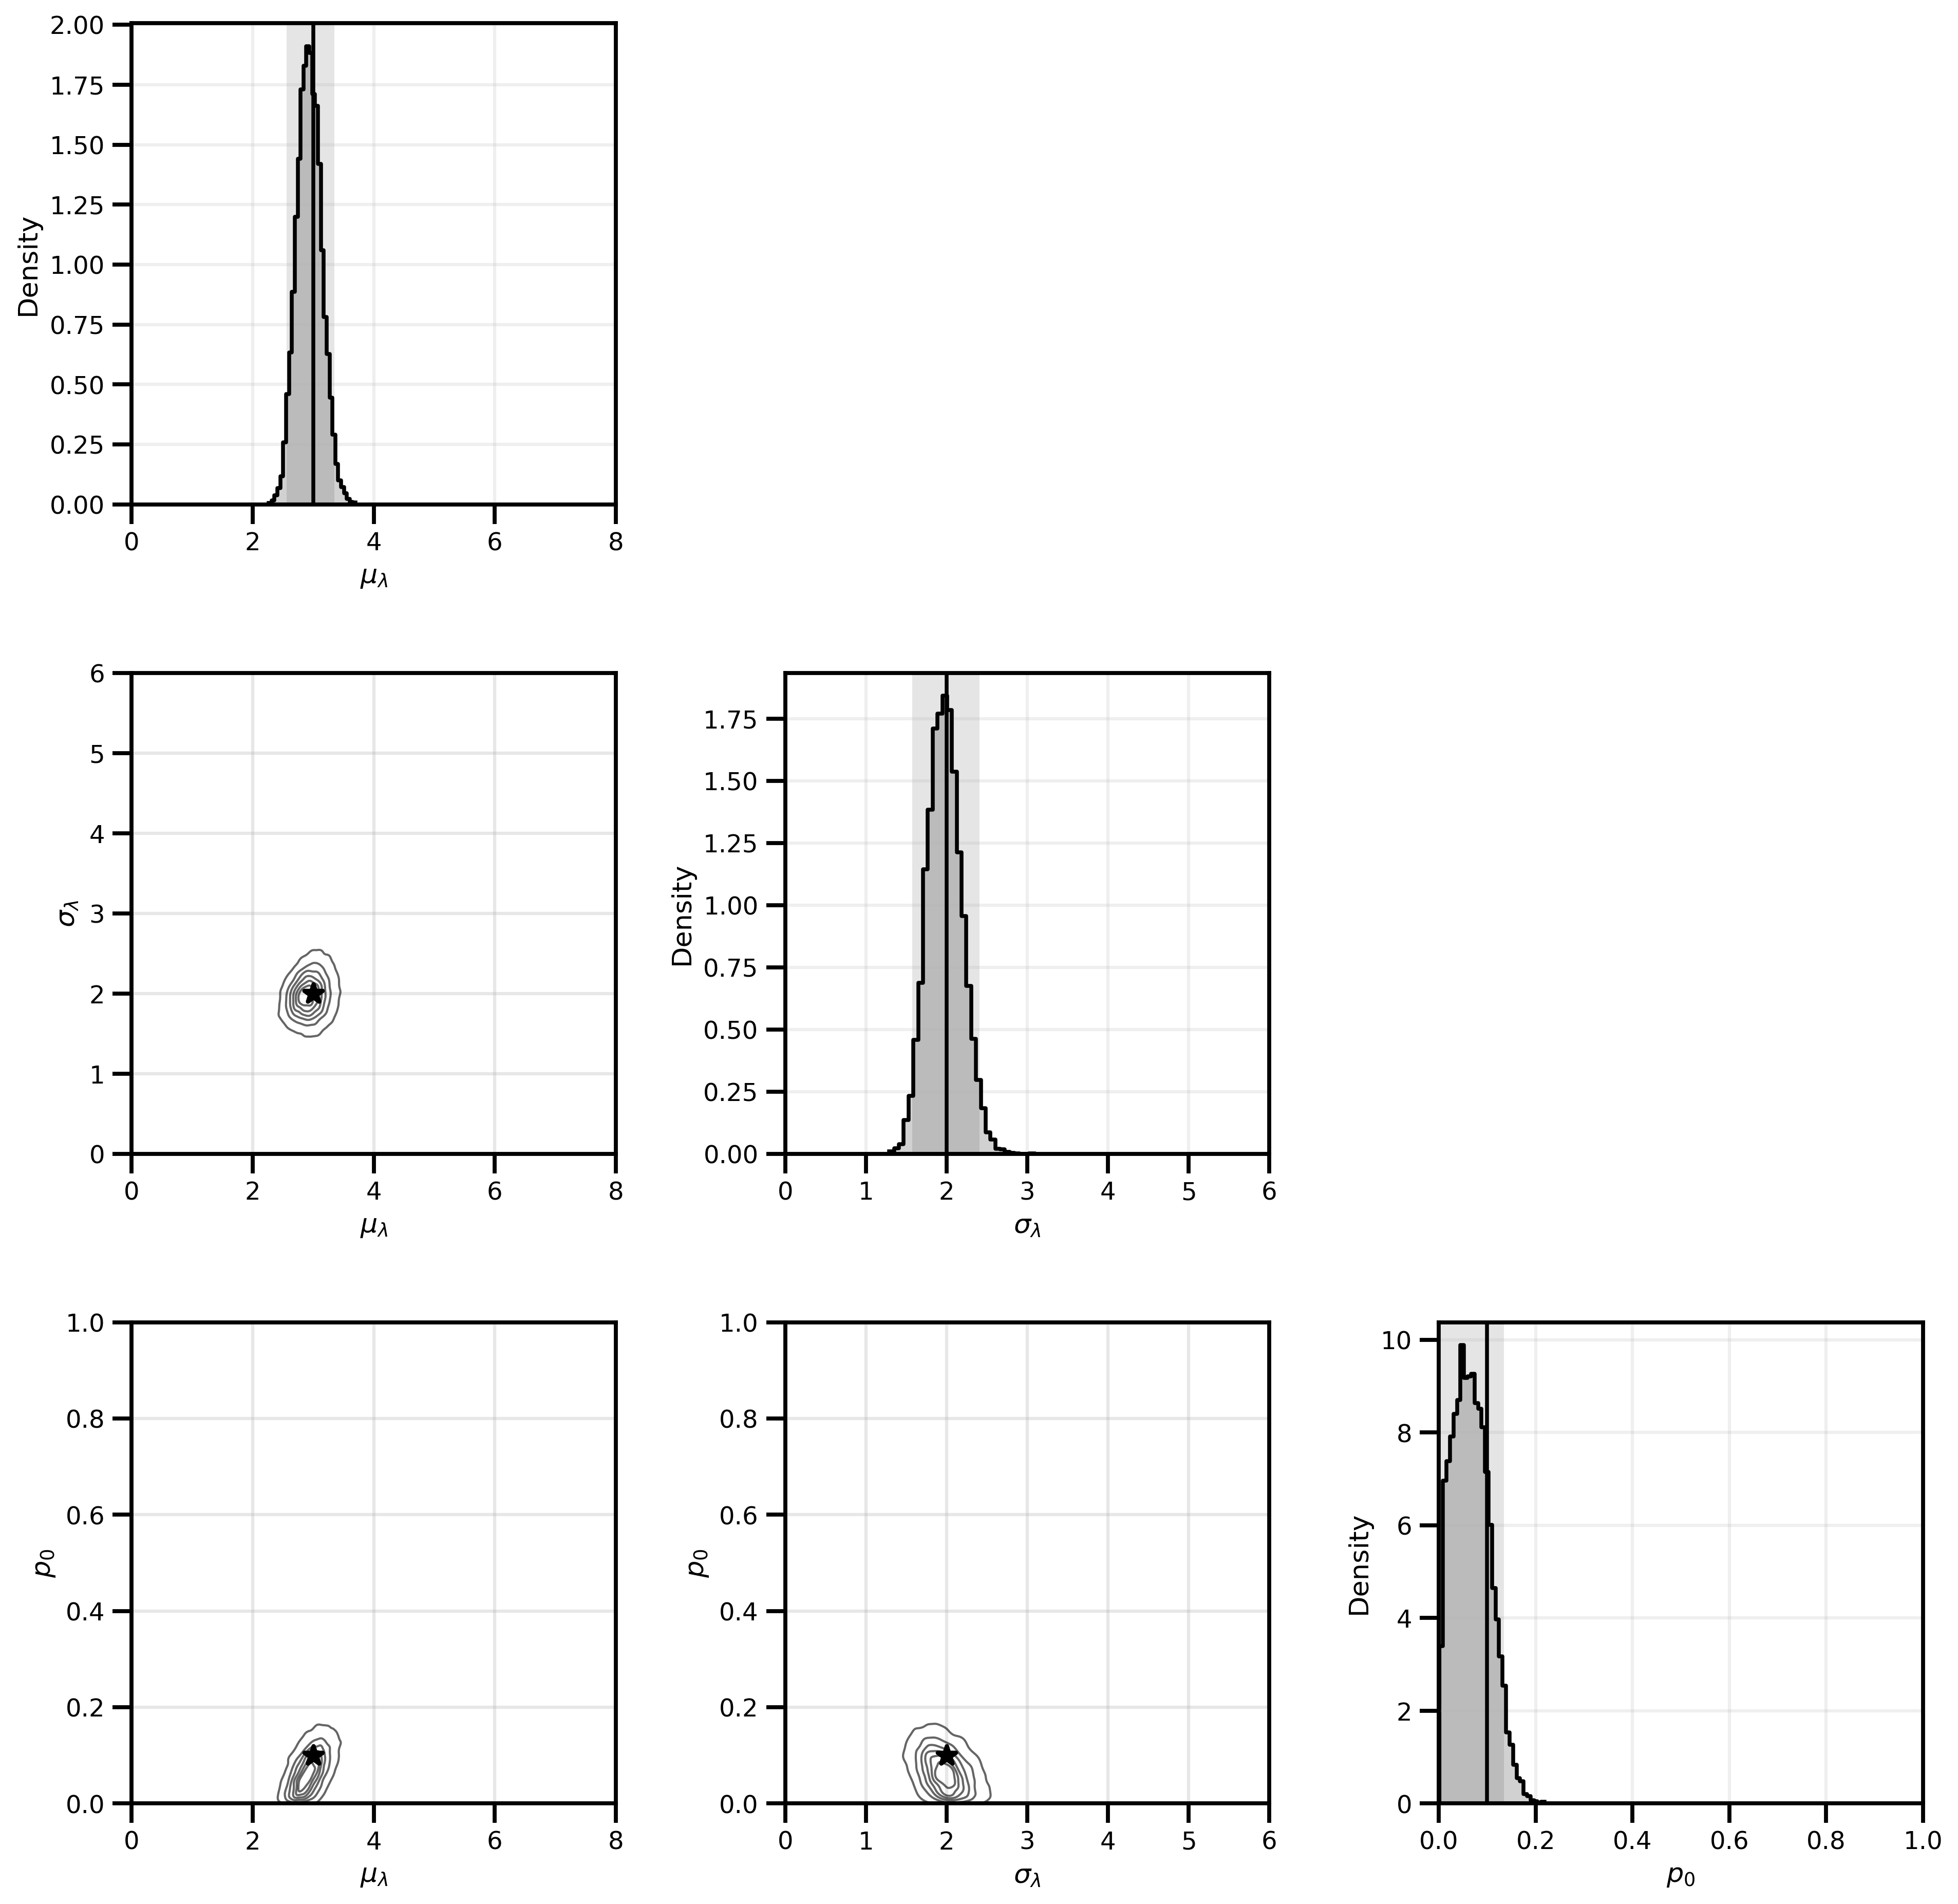

In [5]:
result = inference_results[0]

latex_names = {
    "lambda": r"$\lambda$",
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "p_zero": r"$p_0$",
}

xlims_by_param = {
    "lambda": (0, 8),
    "mu_lambda": (0, 8),
    "sigma_lambda": (0, 6),
    "p_zero": (0, 1),
}

for model_name, spec in model_specs.items():
    idata = result["models"][model_name]["idata"]
    params = spec["vars"]

    plot_posteriors(
        [(model_name, idata)],
        parameters=params,
        ground_truth={model_name: spec["truth"]},
        parameter_display={p: latex_names.get(p, p) for p in params},
        xlims={p: xlims_by_param[p] for p in params if p in xlims_by_param},
        show_legend=False,
        save_path=f"posterior_{model_name}",
        diagonal_style="hist",
        marginal_style="circle",
        seed=123,
    )

**Bayes Factor**

Initializing SMC sampler...


Sampling 4 chains in 4 jobs


Output()

Running four-model demo inference: homo


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta     0.442  0.017   0.409    0.472      0.000    0.000   12020.0   11638.0   
lambda  2.768  0.106   2.567    2.966      0.001    0.001   12020.0   11638.0   

        r_hat  
eta       1.0  
lambda    1.0  


...

Initializing SMC sampler...


Sampling 4 chains in 4 jobs


Output()

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
eta           0.444  0.027   0.394    0.495      0.000    0.000   11998.0   
sigma_lambda  2.210  0.224   1.797    2.638      0.002    0.002   11873.0   
mu_lambda     2.783  0.174   2.453    3.103      0.002    0.001   11998.0   

              ess_tail  r_hat  
eta            11408.0    1.0  
sigma_lambda   11628.0    1.0  
mu_lambda      11408.0    1.0  
Running four-model demo inference: hetero3


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
eta           0.470  0.030   0.414    0.527      0.000    0.000   11581.0   
sigma_lambda  2.080  0.234   1.652    2.519      0.002    0.002   11172.0   
p_zero        0.062  0.037   0.002    0.126      0.000    0.000   10534.0   
mu_lambda     2.957  0.207   2.577    3.345      0.002    0.001   11581.0   

              ess_tail  r_hat  
eta            11164.0    1.0  
sigma_lambda   11278.0    1.0  
p_zero          8400.0    1.0  
mu_lambda      11164.0    1.0  


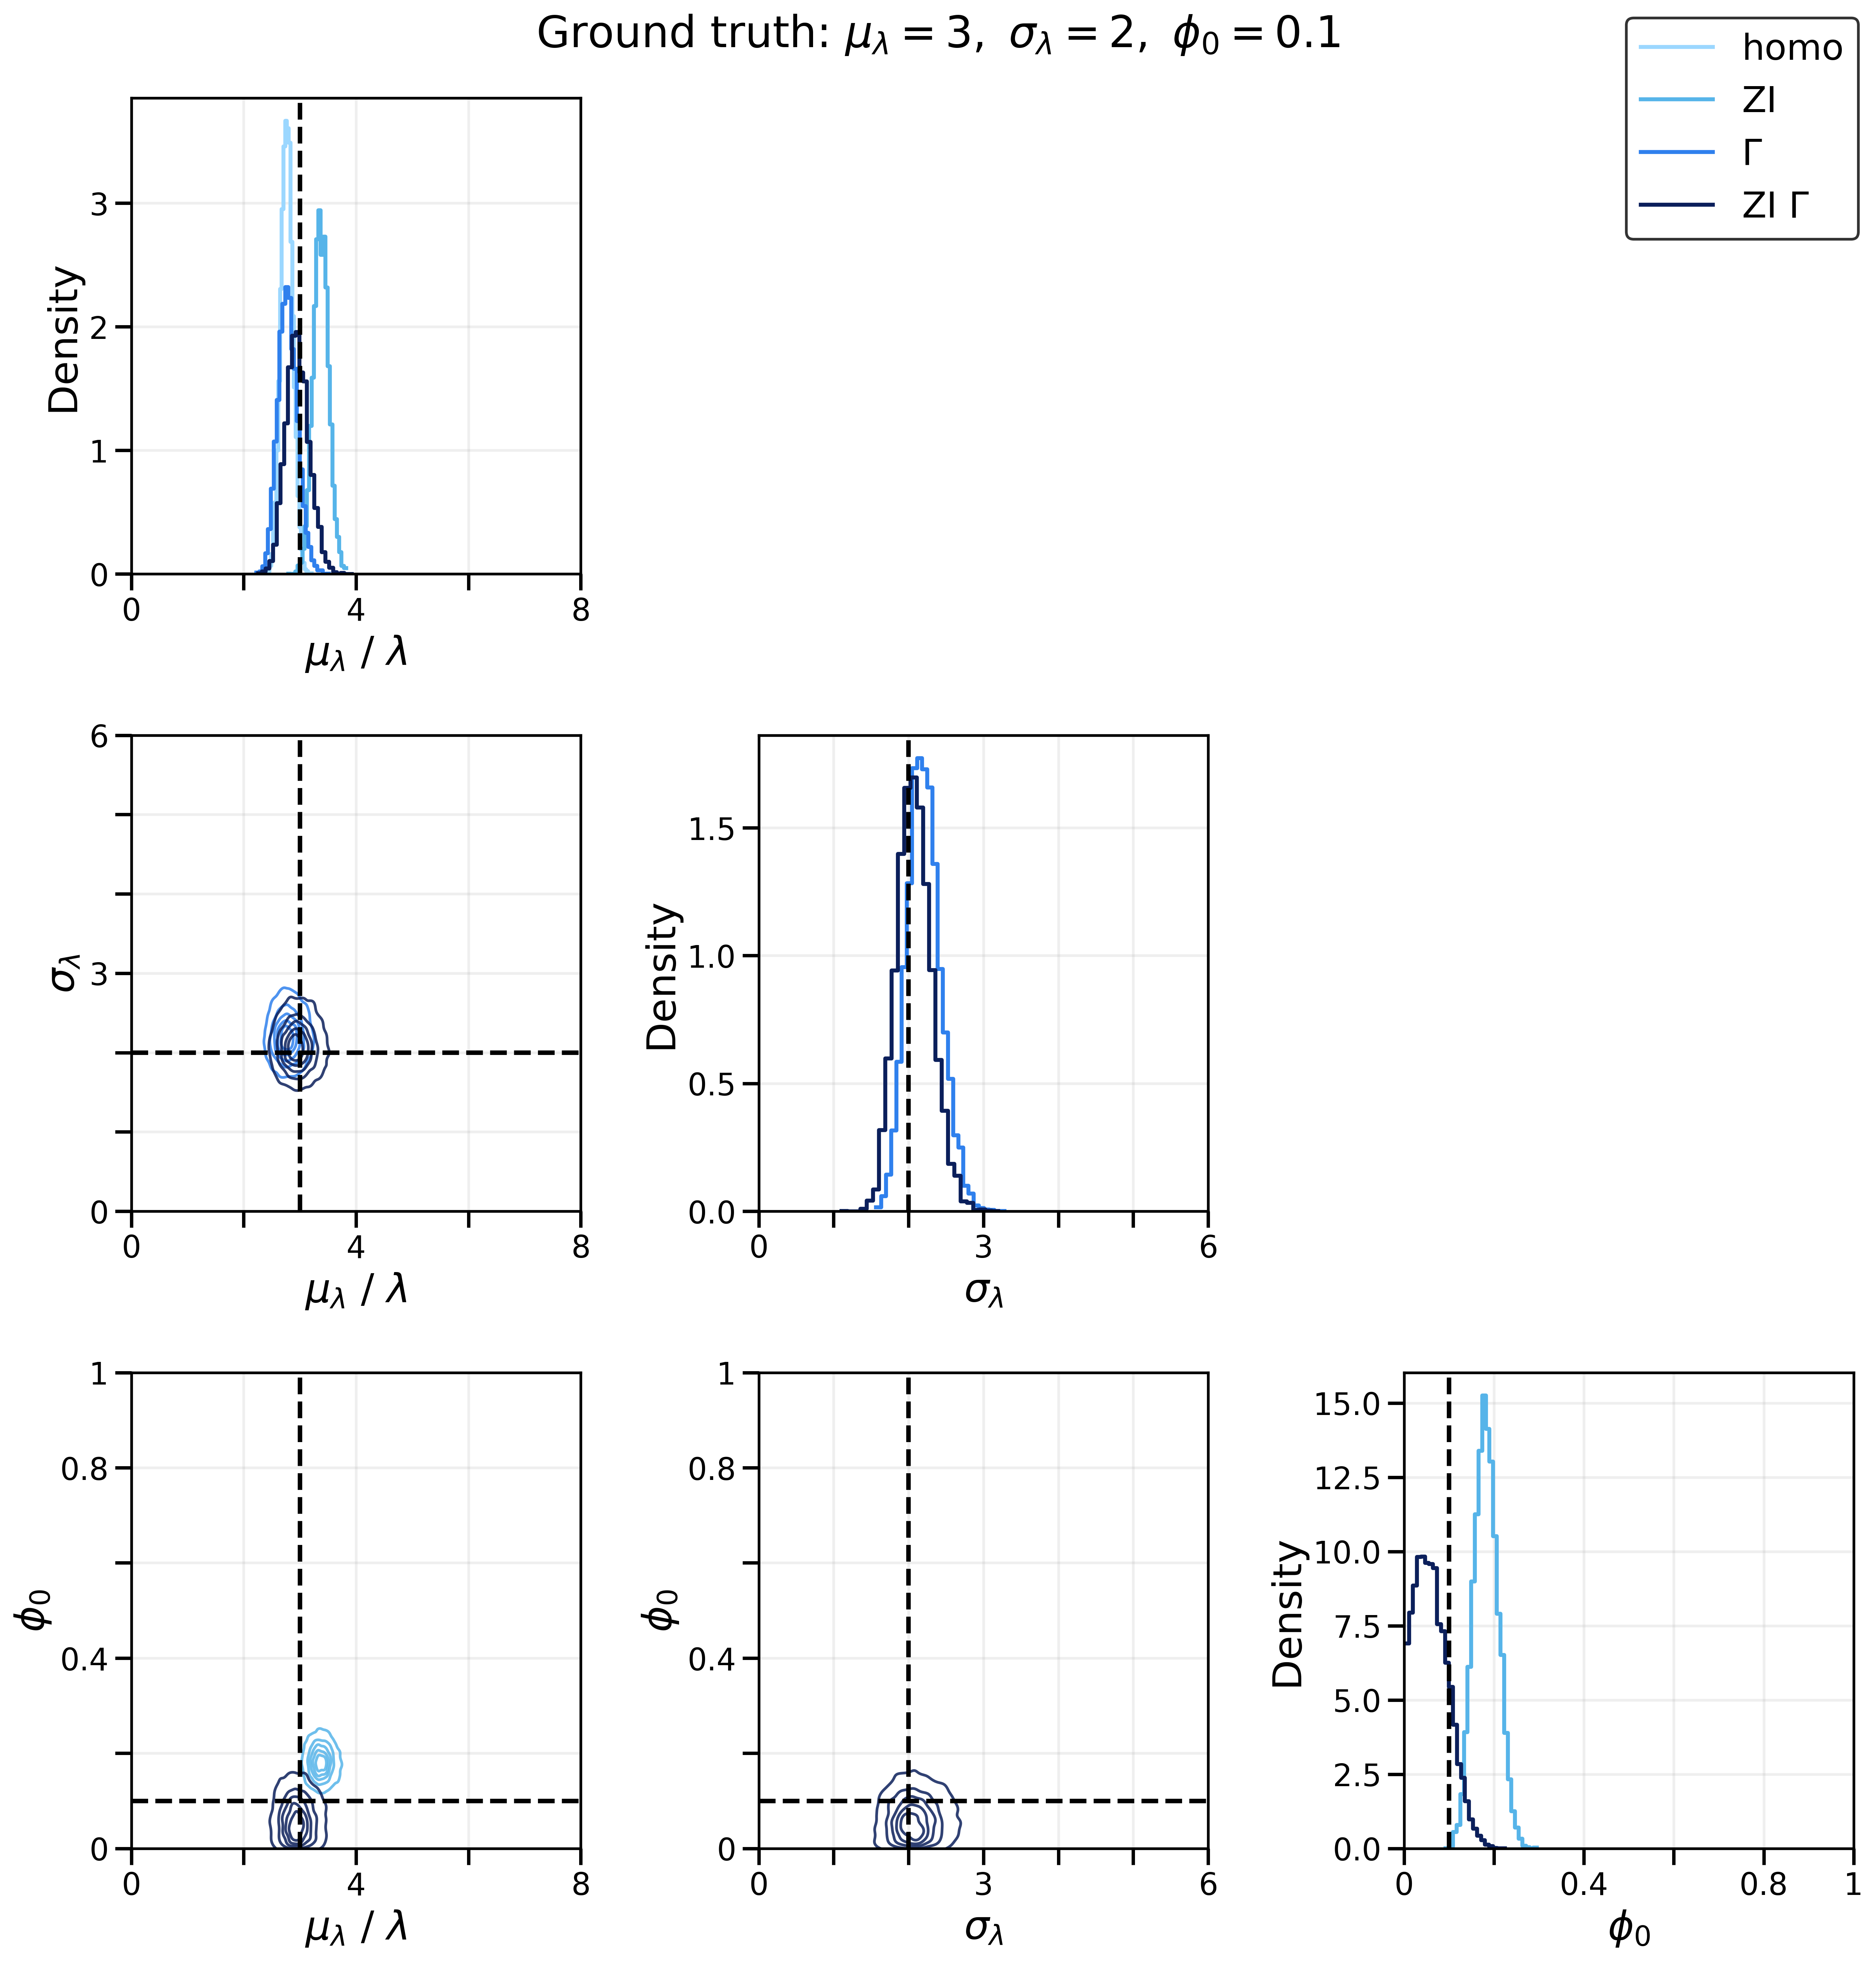

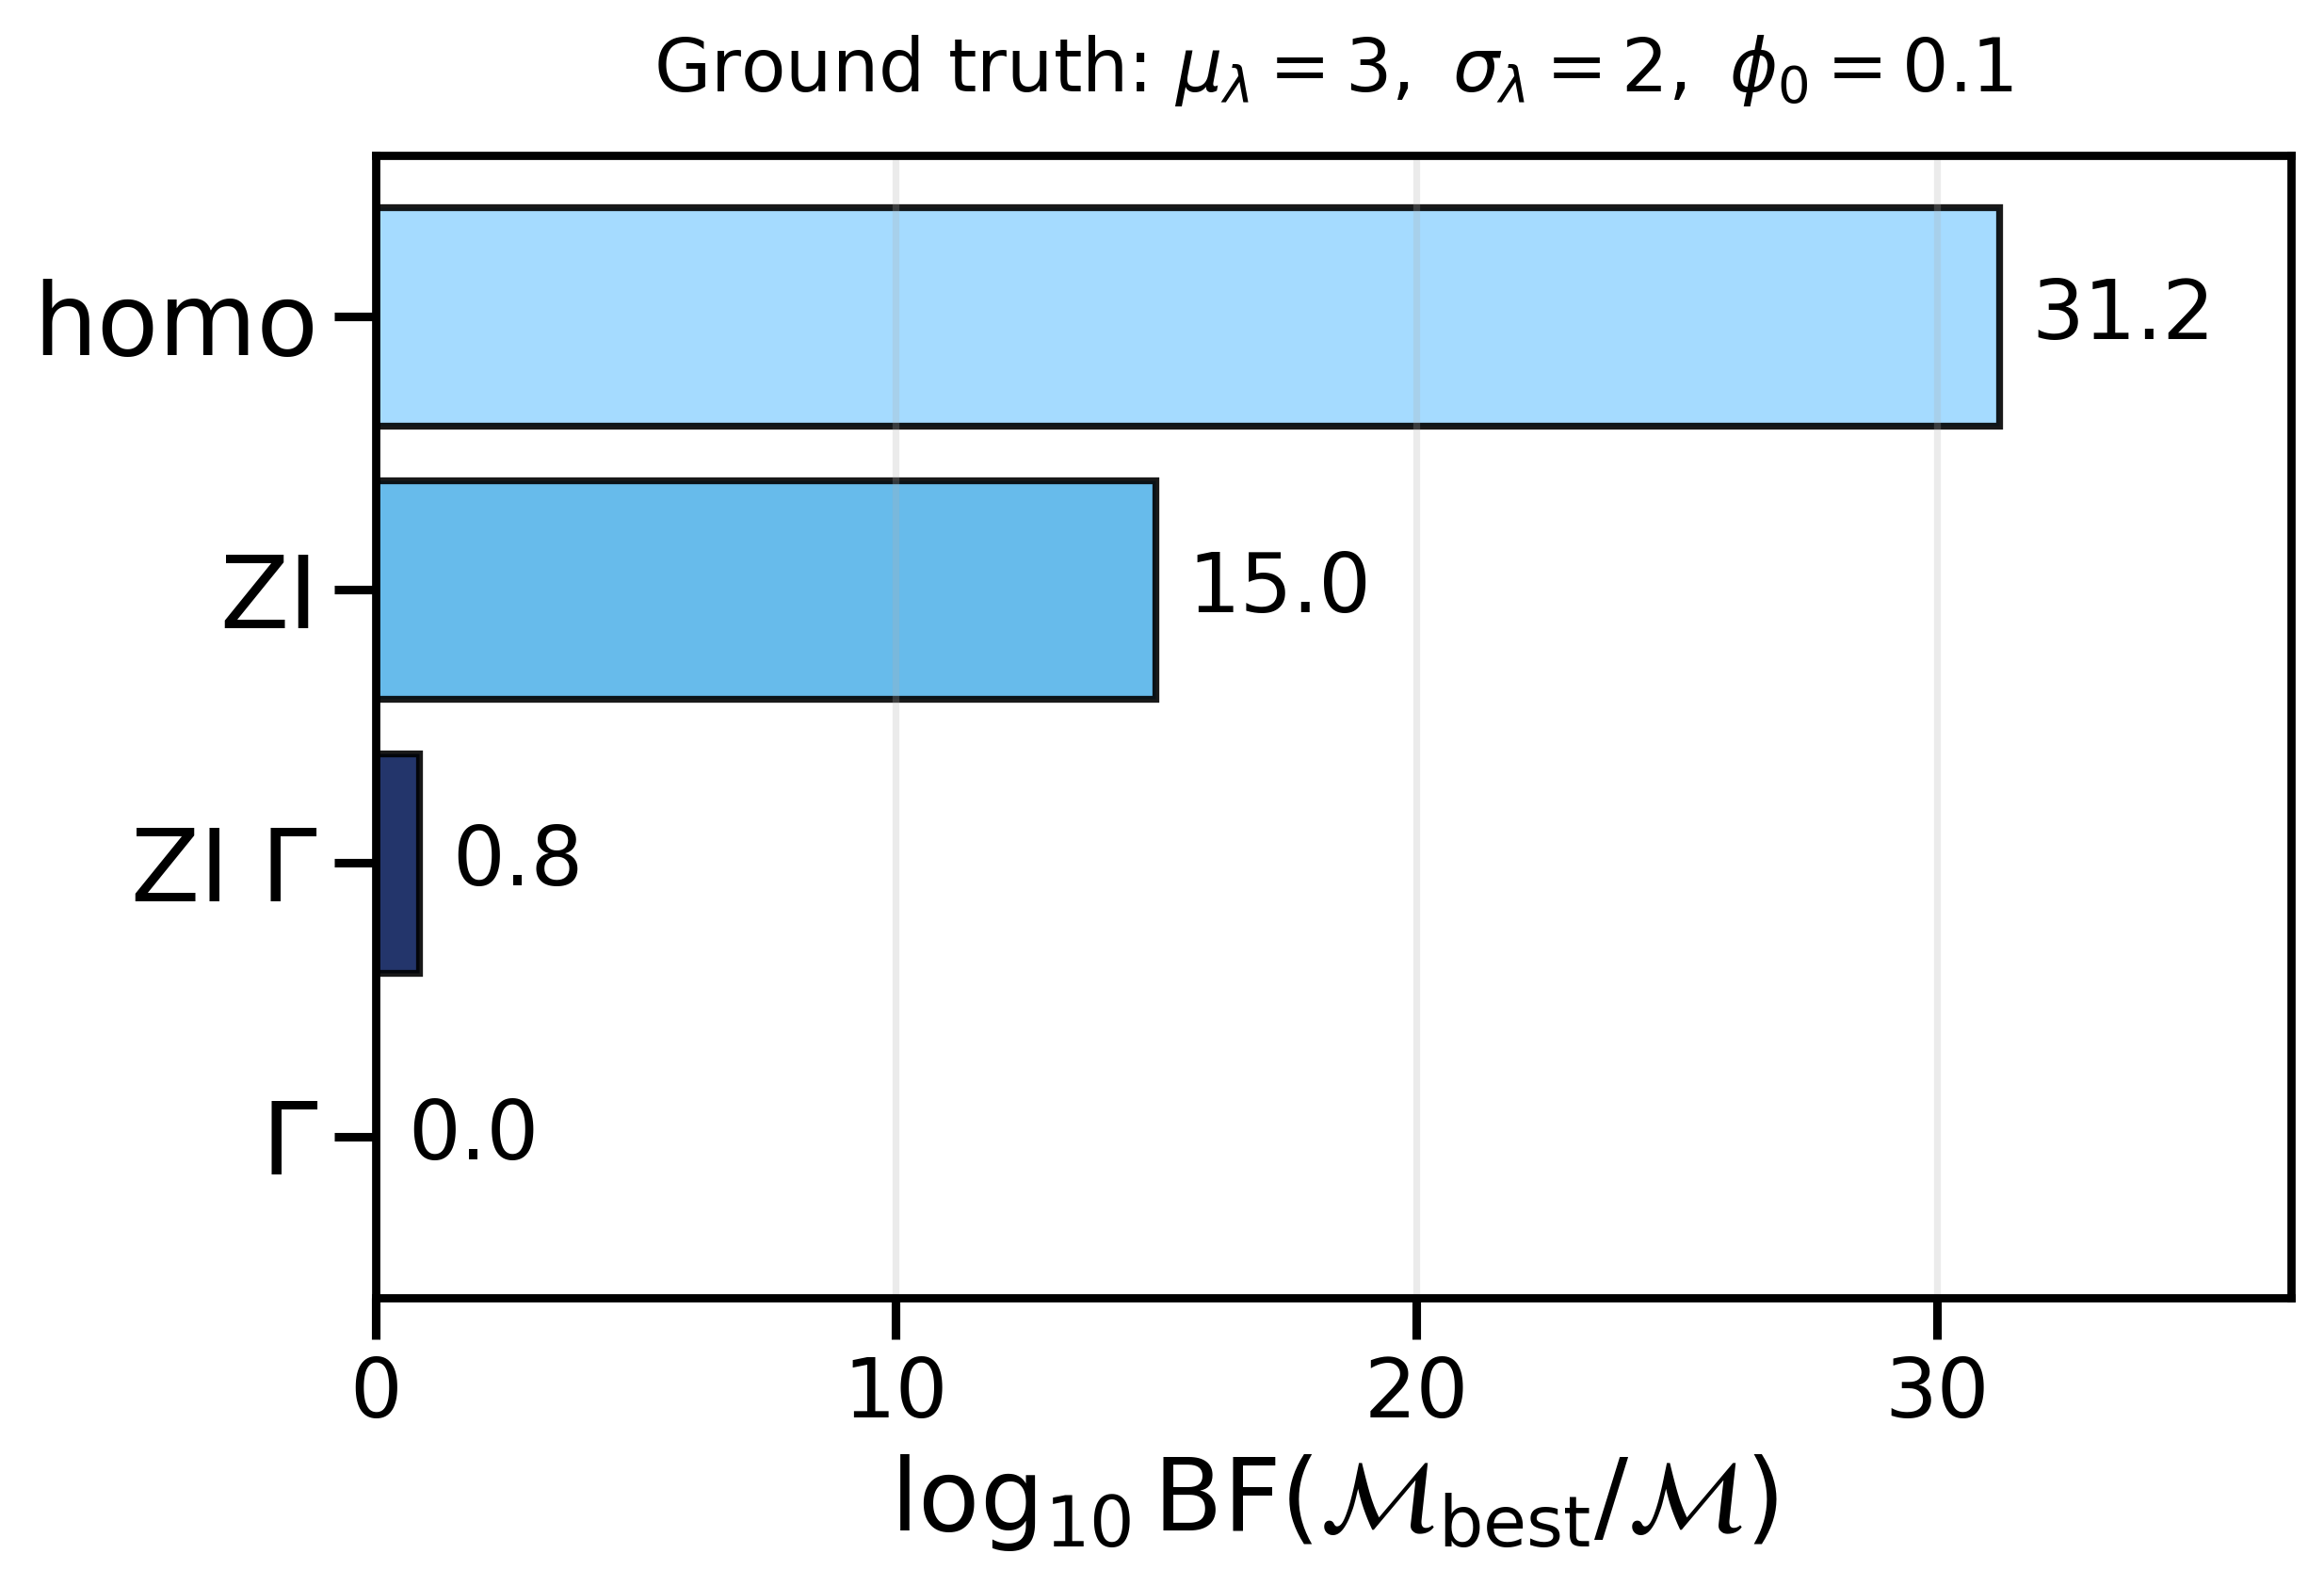

,model,logml
2,Dis2P,-547.412298
3,hetero3,-549.359811
1,Z2P,-581.917583
0,homo,-619.219407


,svg
0,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
1,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...


In [6]:
from inference import smc_log_evidence

DEMO_FOUR_MODEL_ROOT = SECTION_ROOT / "results" / "demo_validation_1_four_models"
DEMO_FOUR_MODEL_FIGURE_ROOT = SECTION_ROOT / "figures" / "demo_validation_1_four_models"
DEMO_FOUR_MODEL_ROOT.mkdir(parents=True, exist_ok=True)
DEMO_FOUR_MODEL_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

FORCE_DEMO_FOUR_MODEL_RERUN = False
DEMO_SMC_DRAWS = 3000
DEMO_CHAINS = 4
DEMO_CORES = 4
DEMO_RANDOM_SEED = 123

MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]
MODEL_DISPLAY = {
    "homo": "homo",
    "Z2P": "ZI",
    "Dis2P": r"$\Gamma$",
    "hetero3": r"ZI $\Gamma$",
}
MODEL_COLORS = {
    "homo": "#9BD7FF",
    "Z2P": "#56B4E9",
    "Dis2P": "#2F80ED",
    "hetero3": "#0B1F5B",
}
MODEL_TO_COMMON_PARAM = {
    "homo": {"mu_lambda": "lambda"},
    "Z2P": {"mu_lambda": "lambda", "p_zero": "p_zero"},
    "Dis2P": {"mu_lambda": "mu_lambda", "sigma_lambda": "sigma_lambda"},
    "hetero3": {"mu_lambda": "mu_lambda", "sigma_lambda": "sigma_lambda", "p_zero": "p_zero"},
}
COMMON_PARAMS = ["mu_lambda", "sigma_lambda", "p_zero"]
COMMON_PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$ / $\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "p_zero": r"$\phi_0$",
}
COMMON_PARAM_LIMITS = {
    "mu_lambda": (0, 8),
    "sigma_lambda": (0, 6),
    "p_zero": (0, 1),
}
COMMON_PARAM_TICKS = {
    "mu_lambda": [0, 2, 4, 6, 8],
    "sigma_lambda": [0, 1, 2, 3, 4, 5, 6],
    "p_zero": [0, 0.2, 0.4, 0.6, 0.8, 1.0],
}
COMMON_PARAM_TICKLABELS = {
    "mu_lambda": ["0", "", "4", "", "8"],
    "sigma_lambda": ["0", "", "", "3", "", "", "6"],
    "p_zero": ["0", "", "0.4", "", "0.8", "1"],
}

FOUR_MODEL_SPECS = {
    "homo": {"fn": inference_homo},
    "Z2P": {"fn": inference_Z2P},
    "Dis2P": {"fn": inference_Dis2P},
    "hetero3": {"fn": inference_hetero3},
}


def save_idata_netcdf(idata: az.InferenceData, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = out_path.with_name(f".{out_path.stem}.{os.getpid()}.tmp{out_path.suffix}")
    if tmp_path.exists():
        tmp_path.unlink()
    az.to_netcdf(idata, str(tmp_path))
    tmp_path.replace(out_path)


def run_or_load_demo_model(
    counts: np.ndarray,
    *,
    model_name: str,
    model_index: int,
    obs_time: float,
) -> az.InferenceData:
    posterior_path = DEMO_FOUR_MODEL_ROOT / f"posterior_{model_name}_smc.nc"
    logml_path = DEMO_FOUR_MODEL_ROOT / f"log_marginal_likelihood_{model_name}_smc.csv"

    if posterior_path.exists() and logml_path.exists() and not FORCE_DEMO_FOUR_MODEL_RERUN:
        return az.from_netcdf(str(posterior_path))

    kwargs = dict(
        draws=DEMO_SMC_DRAWS,
        chains=DEMO_CHAINS,
        cores=DEMO_CORES,
        lambda_prior_bounds=(-5.0, 2.0),
        random_seed=DEMO_RANDOM_SEED + model_index,
    )
    if model_name in {"Z2P", "hetero3"}:
        kwargs["p_prior_bounds"] = (1.0, 1.0)
    if model_name in {"Dis2P", "hetero3"}:
        kwargs["std_prior_factor"] = 5.0

    print(f"Running four-model demo inference: {model_name}")
    pack = FOUR_MODEL_SPECS[model_name]["fn"](counts, obs_time, **kwargs)
    idata = pack["idata"]

    save_idata_netcdf(idata, posterior_path)
    pd.DataFrame(
        [{"model": model_name, "logml": smc_log_evidence(idata), "sampler": "smc"}]
    ).to_csv(logml_path, index=False)
    return idata


def posterior_values_common(
    idata: az.InferenceData,
    *,
    model_name: str,
    common_param: str,
    sample_size: int = 8000,
    seed: int = 123,
) -> np.ndarray:
    source_param = MODEL_TO_COMMON_PARAM.get(model_name, {}).get(common_param)
    if source_param is None or source_param not in idata.posterior:
        return np.array([], dtype=float)

    values = idata.posterior[source_param].stack(sample=("chain", "draw")).values.ravel()
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size > sample_size:
        rng = np.random.default_rng(seed)
        values = values[rng.choice(values.size, sample_size, replace=False)]
    return values


def apply_ticks(ax, *, xparam: str | None = None, yparam: str | None = None) -> None:
    if xparam in COMMON_PARAM_TICKS:
        ax.set_xticks(COMMON_PARAM_TICKS[xparam])
        ax.set_xticklabels(COMMON_PARAM_TICKLABELS[xparam])
    if yparam in COMMON_PARAM_TICKS:
        ax.set_yticks(COMMON_PARAM_TICKS[yparam])
        ax.set_yticklabels(COMMON_PARAM_TICKLABELS[yparam])


def plot_overlapping_four_model_posteriors(
    idatas_by_model: dict[str, az.InferenceData],
    *,
    truth: dict[str, float],
    save_path: Path,
    bins: int = 25,
    dpi: int = 350,
) -> Path:
    samples = {
        model_name: {
            param: posterior_values_common(
                idata,
                model_name=model_name,
                common_param=param,
                seed=DEMO_RANDOM_SEED + 13 * i,
            )
            for i, param in enumerate(COMMON_PARAMS)
        }
        for model_name, idata in idatas_by_model.items()
    }

    npar = len(COMMON_PARAMS)
    fig, axes = plt.subplots(
        npar,
        npar,
        figsize=(4.8 * npar, 4.8 * npar),
        dpi=dpi,
        constrained_layout=True,
    )
    fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.08, wspace=0.08, hspace=0.08)

    for irow, rowpar in enumerate(COMMON_PARAMS):
        for icol, colpar in enumerate(COMMON_PARAMS):
            ax = axes[irow, icol]
            ax.set_facecolor("white")
            ax.minorticks_off()
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)
                spine.set_color("black")

            if icol > irow:
                ax.axis("off")
                continue

            for model_name in MODEL_ORDER:
                color = MODEL_COLORS[model_name]
                label = MODEL_DISPLAY[model_name]

                if icol == irow:
                    vals = samples[model_name][rowpar]
                    if vals.size == 0:
                        continue
                    sns.histplot(
                        vals,
                        bins=bins,
                        stat="density",
                        element="step",
                        fill=False,
                        ax=ax,
                        color=color,
                        linewidth=2.2,
                        label=label if irow == 0 else None,
                    )
                else:
                    xvals = samples[model_name][colpar]
                    yvals = samples[model_name][rowpar]
                    if xvals.size == 0 or yvals.size == 0:
                        continue
                    n = min(xvals.size, yvals.size)
                    sns.kdeplot(
                        x=xvals[:n],
                        y=yvals[:n],
                        ax=ax,
                        color=color,
                        linewidths=1.5,
                        levels=6,
                        fill=False,
                        alpha=0.85,
                    )

            if icol == irow:
                ax.axvline(truth[rowpar], color="black", linestyle="--", linewidth=2.5)
                ax.set_xlabel(COMMON_PARAM_DISPLAY[rowpar], fontsize=22)
                ax.set_ylabel("Density", fontsize=22)
                ax.set_xlim(*COMMON_PARAM_LIMITS[rowpar])
                apply_ticks(ax, xparam=rowpar)
            else:
                ax.axvline(truth[colpar], color="black", linestyle="--", linewidth=2.5)
                ax.axhline(truth[rowpar], color="black", linestyle="--", linewidth=2.5)
                ax.set_xlabel(COMMON_PARAM_DISPLAY[colpar], fontsize=22)
                ax.set_ylabel(COMMON_PARAM_DISPLAY[rowpar], fontsize=22)
                ax.set_xlim(*COMMON_PARAM_LIMITS[colpar])
                ax.set_ylim(*COMMON_PARAM_LIMITS[rowpar])
                apply_ticks(ax, xparam=colpar, yparam=rowpar)

            ax.tick_params(axis="both", which="major", labelsize=17)
            ax.grid(alpha=0.2)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", frameon=True, edgecolor="black", fontsize=20)

    gt_label = (
        rf"$\mu_\lambda={truth['mu_lambda']:g},\ "
        rf"\sigma_\lambda={truth['sigma_lambda']:g},\ "
        rf"\phi_0={truth['p_zero']:g}$"
    )
    fig.suptitle(rf"Ground truth: {gt_label}", fontsize=24, y=1.04)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)
    plt.show()
    return save_path


def plot_demo_bayes_factor_vs_best(
    logml_df: pd.DataFrame,
    *,
    truth: dict[str, float],
    save_path: Path,
    dpi: int = 350,
) -> Path:
    df = logml_df.copy().sort_values("logml", ascending=False)
    best_model = str(df.iloc[0]["model"])
    best_logml = float(df.iloc[0]["logml"])
    df["log10_BF_best_vs_model"] = (best_logml - df["logml"]) / np.log(10.0)
    df["model_label"] = df["model"].map(MODEL_DISPLAY).fillna(df["model"])
    df = df.sort_values("log10_BF_best_vs_model", ascending=True)

    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=dpi)
    bars = ax.barh(
        df["model_label"],
        df["log10_BF_best_vs_model"],
        color=[MODEL_COLORS.get(m, "black") if m != best_model else "black" for m in df["model"]],
        edgecolor="black",
        linewidth=1.5,
        alpha=0.9,
    )

    xmax = float(df["log10_BF_best_vs_model"].max())
    ax.set_xlim(0, xmax * 1.18 if xmax > 0 else 1)
    ax.axvline(0, color="black", linewidth=1.5)

    for bar, value in zip(bars, df["log10_BF_best_vs_model"]):
        ax.text(
            value + max(xmax * 0.02, 0.05),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}",
            va="center",
            ha="left",
            fontsize=18,
            color="black",
        )

    ax.set_xlabel(r"$\log_{10}\mathrm{BF}(\mathcal{M}_{\mathrm{best}}/\mathcal{M})$", fontsize=22)
    ax.tick_params(axis="x", which="major", labelsize=18)
    ax.tick_params(axis="y", which="major", labelsize=22)
    ax.minorticks_off()
    ax.grid(True, axis="x", alpha=0.25)
    ax.grid(False, axis="y")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.8)
        spine.set_color("black")

    gt_label = (
        rf"$\mu_\lambda={truth['mu_lambda']:g},\ "
        rf"\sigma_\lambda={truth['sigma_lambda']:g},\ "
        rf"\phi_0={truth['p_zero']:g}$"
    )
    ax.set_title(rf"Ground truth: {gt_label}", fontsize=16, pad=14)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, format="svg", bbox_inches="tight", pad_inches=0.2, transparent=True)
    plt.show()
    return save_path


counts = np.asarray(datasets[0], dtype=int)
truth = {
    "mu_lambda": float(demo_params[0]["mu_lambda"]),
    "sigma_lambda": float(demo_params[0]["sd_lambda"]),
    "p_zero": float(demo_params[0]["p0_lambda"]),
}

four_model_idatas = {}
logml_rows = []
for model_index, model_name in enumerate(MODEL_ORDER):
    idata = run_or_load_demo_model(
        counts,
        model_name=model_name,
        model_index=model_index,
        obs_time=T,
    )
    four_model_idatas[model_name] = idata
    logml_rows.append({"model": model_name, "logml": smc_log_evidence(idata)})

demo_four_model_logml_df = pd.DataFrame(logml_rows).sort_values("logml", ascending=False)
demo_four_model_logml_df.to_csv(DEMO_FOUR_MODEL_ROOT / "log_marginal_likelihoods_four_models_smc.csv", index=False)

posterior_svg = plot_overlapping_four_model_posteriors(
    four_model_idatas,
    truth=truth,
    save_path=DEMO_FOUR_MODEL_FIGURE_ROOT / "overlapping_posteriors_four_models.svg",
)

bf_svg = plot_demo_bayes_factor_vs_best(
    demo_four_model_logml_df,
    truth=truth,
    save_path=DEMO_FOUR_MODEL_FIGURE_ROOT / "bayes_factor_vs_best_four_models.svg",
)

display(demo_four_model_logml_df)
pd.DataFrame({"svg": [str(posterior_svg), str(bf_svg)]})
